In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df =pd.read_csv(r"C:\Users\CPADM\Downloads\Dataset for Data Analytics - Sheet1.csv")

In [8]:
#Basic Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
None


In [9]:
# Basic information
print(df.describe())

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


In [10]:
# Missing values
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [11]:
#Descriptive Statistics
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [12]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,04-01-2023,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,23-08-2024,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,27-02-2024,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,15-10-2023,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,08-05-2025,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


Top Selling Products

In [13]:
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

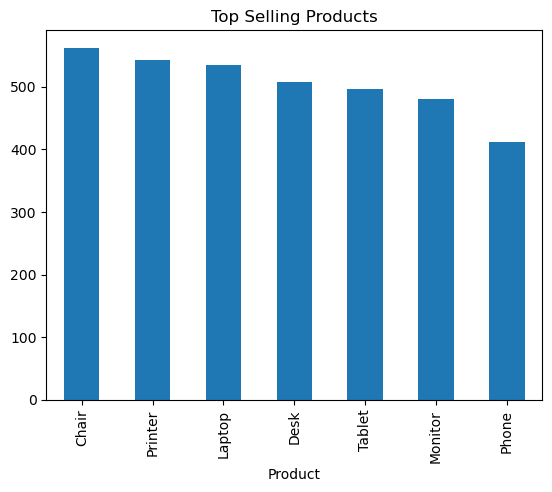

In [14]:
top_products.head(10).plot(kind='bar')
plt.title("Top Selling Products")
plt.show()

Payment Method Analysis

In [15]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

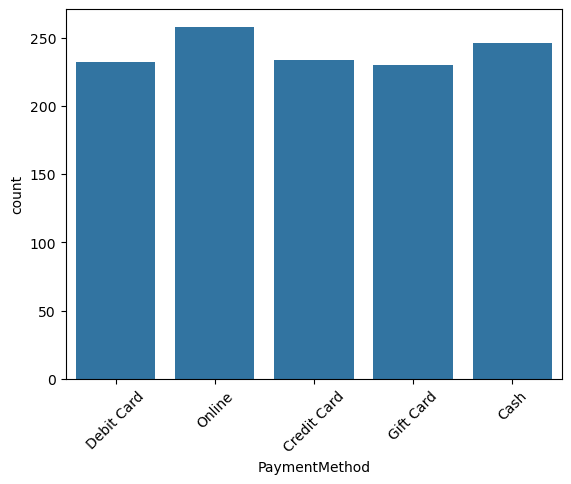

In [16]:
sns.countplot(data=df,x='PaymentMethod')
plt.xticks(rotation=45)
plt.show()

Order Status Analysis

In [17]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

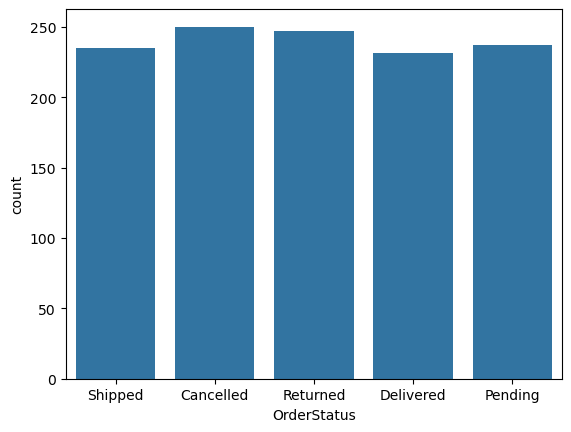

In [18]:
sns.countplot(data=df,x='OrderStatus')
plt.show()

Referral Source Analysis

In [19]:
df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

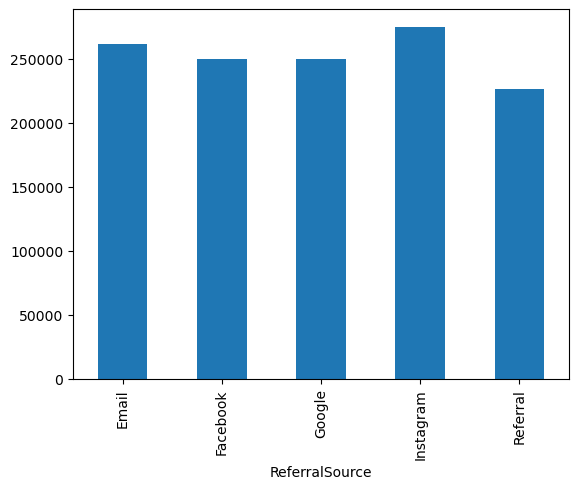

In [20]:
df.groupby('ReferralSource')['TotalPrice'].sum().plot(kind='bar')
plt.show()

Coupon Usage Analysis

In [21]:
df['CouponCode'].notnull().sum()

np.int64(891)

In [22]:
df.groupby(df['CouponCode'].notnull())['TotalPrice'].mean()

CouponCode
False    1043.370259
True     1057.643715
Name: TotalPrice, dtype: float64

Distribution Analysis
Total Price Distribution

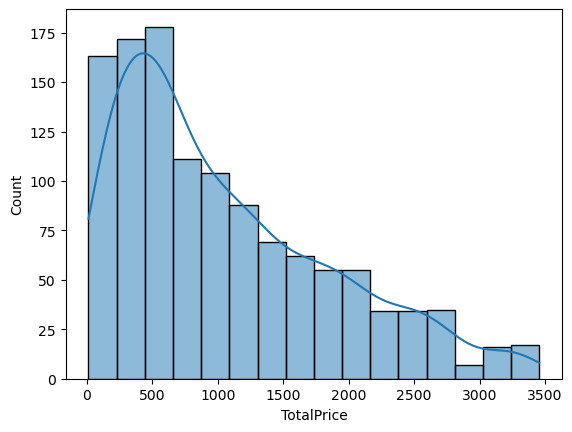

In [23]:
sns.histplot(df['TotalPrice'],kde=True)
plt.show()

Outlier Detection
Total Price

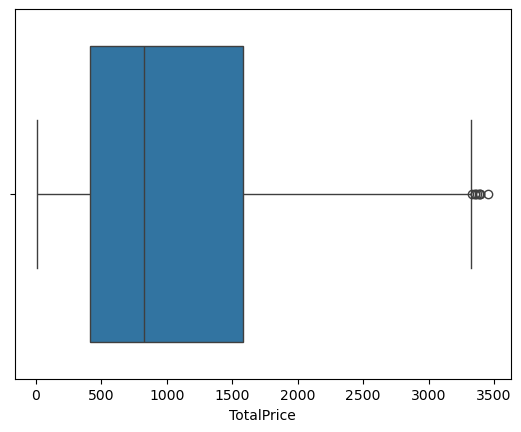

In [24]:
sns.boxplot(x=df['TotalPrice'])
plt.show()

Quantity

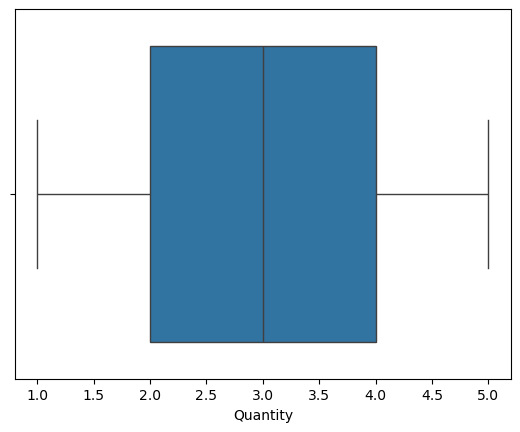

In [25]:
sns.boxplot(x=df['Quantity'])
plt.show()

  Correlation Analysis

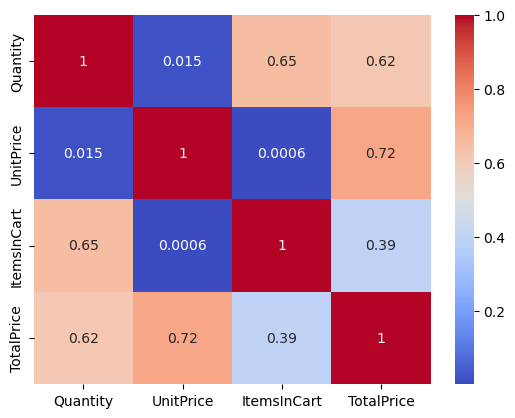

In [26]:
numeric_cols = ['Quantity','UnitPrice','ItemsInCart','TotalPrice']
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [27]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].describe()

df['Product'].value_counts().head(10)

df['PaymentMethod'].value_counts()

df['OrderStatus'].value_counts()

df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

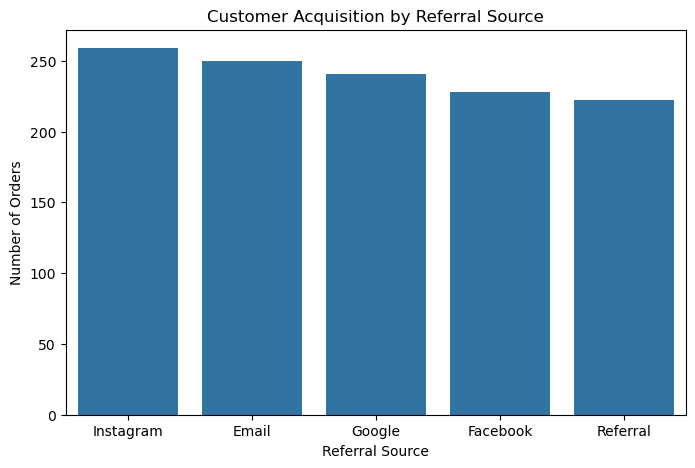

In [28]:
referral_counts = df['ReferralSource'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=referral_counts.index,
            y=referral_counts.values)

plt.title("Customer Acquisition by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")
plt.show()

Key Findings

✅ Instagram is the leading referral source with 259 customer orders.

✅ Social media platforms (Instagram and Facebook) together contributed a significant portion of total traffic.

✅ Referral programs generated the lowest number of orders, indicating potential opportunities for improvement.